# 06 — Modelos Neurais e Comparação Final

Aqui treinamos os modelos neurais (PyTorch) e fazemos a **comparação definitiva**
contra os baselines, todos sob o **mesmo protocolo** e nos **mesmos usuários
held-out** — a prova de qual abordagem recomenda melhor.

**Quatro modelos, uma régua:**
1. **Popularidade** — ranqueia candidatos pela popularidade global do produto.
2. **Histórico (frequência)** — ranqueia pelos itens que o usuário mais compra.
3. **NCF (apenas IDs)** — rede neural com embeddings de usuário e produto
   (`notebook 03`). Testa se *collaborative filtering* puro basta.
4. **MLP com features** — embeddings de produto/aisle/department + features de
   recência/frequência (`notebook 05`).

> 🔬 **Protocolo: re-ranking de candidatos.** Cada usuário tem um conjunto de
> *candidatos* (os produtos que já comprou). Cada modelo atribui um *score* a
> cada candidato; ranqueamos e comparamos o top-K com o próximo pedido real. É
> mais realista para recompra do que varrer o catálogo inteiro — por isso os
> números aqui são **mais altos** que os do `notebook 04` (que usou *full
> catalog*). O que importa é a **comparação relativa** sob a mesma régua.

## 0. Setup

In [1]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'


def find_project_root(marker: str = 'pyproject.toml') -> Path:
    '''Sobe na arvore de diretorios ate encontrar o marcador do projeto.'''
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Marcador {marker} nao encontrado a partir de {current}')


PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
IMG_DIR = PROJECT_ROOT / 'docs' / 'img' / 'model'
MODELS_DIR.mkdir(exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)
print('device:', device, '| GPU:', torch.cuda.get_device_name(0) if device == 'cuda' else '-')

device: cpu | GPU: -


## 1. Dados: candidatos, rótulos e ground truth

- `candidate_features` (do nb05) — candidatos com features e a coluna `split`.
- `val_ground_truth` — o próximo pedido real (alvo da avaliação).
- Pré-computamos os **grupos por usuário** no conjunto de avaliação para ranquear
  rápido.

In [2]:
features = pd.read_parquet(PROCESSED_DIR / 'candidate_features.parquet')
val = pd.read_parquet(PROCESSED_DIR / 'val_ground_truth.parquet')

valid = val.dropna(subset=['product_idx']).copy()
valid['user_idx'] = valid['user_idx'].astype('int32')
valid['product_idx'] = valid['product_idx'].astype('int32')
ground_truth = {int(u): set(map(int, g))
                for u, g in valid.groupby('user_idx')['product_idx'].apply(set).items()}

eval_df = features[features['split'] == 'eval'].sort_values('user_idx').reset_index(drop=True)
train_df = features[features['split'] == 'train'].reset_index(drop=True)
eval_items = eval_df['product_idx'].to_numpy()
uniq, starts = np.unique(eval_df['user_idx'].to_numpy(), return_index=True)
bounds = list(starts) + [len(eval_df)]
eval_groups = [(int(uniq[i]), bounds[i], bounds[i + 1]) for i in range(len(uniq))]
print('Usuários eval:', f'{len(eval_groups):,}', '| candidatos eval:', f'{len(eval_df):,}')

Usuários eval: 26,241 | candidatos eval: 1,690,666


## 2. Protocolo de avaliação e métricas

Reusamos as quatro métricas de ranking do `notebook 04`. A função
`evaluate_scores` recebe **um vetor de scores** (um por candidato) e mede o
ranking de cada usuário — qualquer modelo entra pela mesma porta (princípio
aberto/fechado, SOLID).

In [3]:
def precision_at_k(recs: list[int], truth: set[int], k: int) -> float:
    '''Fracao dos k recomendados presentes no proximo pedido.'''
    return sum(1 for x in recs[:k] if x in truth) / k


def recall_at_k(recs: list[int], truth: set[int], k: int) -> float:
    '''Fracao do proximo pedido coberta pelos k recomendados.'''
    return sum(1 for x in recs[:k] if x in truth) / len(truth) if truth else 0.0


def ndcg_at_k(recs: list[int], truth: set[int], k: int) -> float:
    '''Ganho cumulativo descontado normalizado: premia acertos no topo.'''
    dcg = sum(1.0 / np.log2(r + 2) for r, x in enumerate(recs[:k]) if x in truth)
    ideal = sum(1.0 / np.log2(r + 2) for r in range(min(len(truth), k)))
    return dcg / ideal if ideal > 0 else 0.0


def average_precision_at_k(recs: list[int], truth: set[int], k: int) -> float:
    '''Precisao media nas posicoes em que houve acerto.'''
    if not truth:
        return 0.0
    score = hits = 0.0
    for r, x in enumerate(recs[:k]):
        if x in truth:
            hits += 1
            score += hits / (r + 1)
    return score / min(len(truth), k)


METRICS = {'Precision@K': precision_at_k, 'Recall@K': recall_at_k,
           'NDCG@K': ndcg_at_k, 'MAP@K': average_precision_at_k}


def evaluate_scores(scores: np.ndarray, k: int = 10) -> dict[str, float]:
    '''Ranqueia os candidatos de cada usuario por 'scores' e tira a media das metricas.'''
    totals = {name: 0.0 for name in METRICS}
    for user, start, end in eval_groups:
        order = np.argsort(-scores[start:end], kind='stable')
        recs = [int(x) for x in eval_items[start:end][order[:k]]]
        for name, fn in METRICS.items():
            totals[name] += fn(recs, ground_truth[user], k)
    return {name: total / len(eval_groups) for name, total in totals.items()}

## 3. Baselines (sob o mesmo protocolo)

Os baselines viram apenas **colunas de score**: popularidade usa `p_n_users`;
histórico usa `n_orders` (frequência). Sem treino — só ordenam os candidatos.

In [4]:
scores_by_model = {}
scores_by_model['Popularidade'] = eval_df['p_n_users'].to_numpy(dtype='float64')
scores_by_model['Histórico (freq)'] = eval_df['n_orders'].to_numpy(dtype='float64')

for name in ['Popularidade', 'Histórico (freq)']:
    m = evaluate_scores(scores_by_model[name])
    print(f'{name:18s} | ' + '  '.join(f'{k}={v:.4f}' for k, v in m.items()))

Popularidade       | Precision@K=0.1693  Recall@K=0.2142  NDCG@K=0.2373  MAP@K=0.1332
Histórico (freq)   | Precision@K=0.2666  Recall@K=0.3195  NDCG@K=0.3875  MAP@K=0.2625


## 4. Modelo 1 — NCF (apenas IDs)

Rede neural com **embeddings de usuário e de produto** → MLP → `P(interação)`.
Treinada no dataset implícito do `notebook 03` (positivos + *negative sampling*
4:1 por época). Testa a hipótese: *collaborative filtering* puro (só identidades)
é suficiente?

In [5]:
class NCF(nn.Module):
    '''Neural Collaborative Filtering: embeddings de usuario/item + MLP.'''

    def __init__(self, n_users: int, n_items: int, emb_dim: int = 32,
                 layers: tuple = (128, 64, 32), dropout: float = 0.1):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        dims = [2 * emb_dim, *layers]
        blocks = []
        for a, b in zip(dims, dims[1:]):
            blocks += [nn.Linear(a, b), nn.ReLU(), nn.Dropout(dropout)]
        blocks.append(nn.Linear(dims[-1], 1))
        self.mlp = nn.Sequential(*blocks)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)

    def forward(self, users: torch.Tensor, items: torch.Tensor) -> torch.Tensor:
        '''Logit de interacao para cada par (usuario, item).'''
        return self.mlp(torch.cat([self.user_emb(users), self.item_emb(items)], 1)).squeeze(1)

In [6]:
def train_ncf(pos_u: torch.Tensor, pos_i: torch.Tensor, n_items: int,
              n_users: int, epochs: int = 10, n_neg: int = 4, batch: int = 8192) -> NCF:
    '''Treina o NCF com negative sampling uniforme re-amostrado a cada epoca.'''
    model = NCF(n_users, n_items).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()
    for epoch in range(1, epochs + 1):
        neg_u = pos_u.repeat(n_neg)
        neg_i = torch.randint(0, n_items, (neg_u.shape[0],), device=device)
        u = torch.cat([pos_u, neg_u]); i = torch.cat([pos_i, neg_i])
        y = torch.cat([torch.ones(len(pos_u), device=device),
                       torch.zeros(len(neg_u), device=device)])
        perm = torch.randperm(len(u), device=device)
        u, i, y = u[perm], i[perm], y[perm]
        model.train()
        for s in range(0, len(u), batch):
            opt.zero_grad()
            loss = loss_fn(model(u[s:s + batch], i[s:s + batch]), y[s:s + batch])
            loss.backward(); opt.step()
        print(f'  NCF epoch {epoch:2d} | loss={loss.item():.4f}')
    return model


positives = pd.read_parquet(PROCESSED_DIR / 'train_positives.parquet')
n_users = int(positives['user_idx'].max()) + 1
n_items = int(positives['product_idx'].max()) + 1
pos_u = torch.as_tensor(positives['user_idx'].to_numpy(), dtype=torch.long, device=device)
pos_i = torch.as_tensor(positives['product_idx'].to_numpy(), dtype=torch.long, device=device)
ncf = train_ncf(pos_u, pos_i, n_items, n_users, epochs=10)

  NCF epoch  1 | loss=0.2238
  NCF epoch  2 | loss=0.1993
  NCF epoch  3 | loss=0.2008
  NCF epoch  4 | loss=0.1842
  NCF epoch  5 | loss=0.1829
  NCF epoch  6 | loss=0.1862
  NCF epoch  7 | loss=0.1794
  NCF epoch  8 | loss=0.1783
  NCF epoch  9 | loss=0.1748
  NCF epoch 10 | loss=0.1629


In [7]:
@torch.no_grad()
def score_ncf(model: NCF, eval_df: pd.DataFrame) -> np.ndarray:
    '''Pontua cada candidato de avaliacao com o NCF.'''
    model.eval()
    users = torch.as_tensor(eval_df['user_idx'].to_numpy(), dtype=torch.long, device=device)
    items = torch.as_tensor(eval_df['product_idx'].to_numpy(), dtype=torch.long, device=device)
    return model(users, items).cpu().numpy()


scores_by_model['NCF (IDs)'] = score_ncf(ncf, eval_df)
m = evaluate_scores(scores_by_model['NCF (IDs)'])
print('NCF (IDs)          | ' + '  '.join(f'{k}={v:.4f}' for k, v in m.items()))

NCF (IDs)          | Precision@K=0.1760  Recall@K=0.2220  NDCG@K=0.2431  MAP@K=0.1376


## 5. Modelo 2 — MLP com features

Embeddings de **produto + aisle + department** concatenados com as **features
numéricas** (recência, frequência, reorder, popularidade) → MLP →
`P(recompra)`. Padronizamos as features (média/desvio do treino) e aplicamos
*log* nas contagens para domar a escala.

In [8]:
FEATURE_COLS = ['n_orders', 'up_order_share', 'up_reorder_rate', 'up_orders_since_last',
                'up_active_span', 'up_purchase_rate', 'u_n_products', 'u_reorder_rate',
                'p_n_users', 'p_reorder_rate']
LOG_COLS = ['n_orders', 'up_active_span', 'u_n_products', 'p_n_users']


def fit_scaler(train_df: pd.DataFrame) -> tuple[pd.Series, pd.Series]:
    '''Calcula media/desvio das features (apos log nas contagens) no treino.'''
    x = train_df[FEATURE_COLS].copy()
    x[LOG_COLS] = np.log1p(x[LOG_COLS])
    return x.mean(), x.std().replace(0, 1)


def to_tensors(df: pd.DataFrame, mu: pd.Series, sd: pd.Series) -> tuple:
    '''Converte um DataFrame em tensores (produto, aisle, dept, features, label).'''
    x = df[FEATURE_COLS].copy()
    x[LOG_COLS] = np.log1p(x[LOG_COLS])
    x = ((x - mu) / sd).to_numpy(dtype='float32')
    long = lambda col: torch.as_tensor(df[col].to_numpy(), dtype=torch.long, device=device)
    return (long('product_idx'), long('aisle_id'), long('department_id'),
            torch.as_tensor(x, device=device),
            torch.as_tensor(df['label'].to_numpy(dtype='float32'), device=device))


mu, sd = fit_scaler(train_df)
train_t = to_tensors(train_df, mu, sd)
eval_t = to_tensors(eval_df, mu, sd)
n_aisles = int(features['aisle_id'].max()) + 1
n_depts = int(features['department_id'].max()) + 1
print('features padronizadas | aisles:', n_aisles, '| departments:', n_depts)

features padronizadas | aisles: 135 | departments: 22


In [9]:
class FeatureMLP(nn.Module):
    '''Embeddings de produto/aisle/department + features numericas -> MLP.'''

    def __init__(self, n_products: int, n_aisles: int, n_depts: int, n_feats: int,
                 layers: tuple = (128, 64), dropout: float = 0.2):
        super().__init__()
        self.product_emb = nn.Embedding(n_products, 32)
        self.aisle_emb = nn.Embedding(n_aisles, 8)
        self.dept_emb = nn.Embedding(n_depts, 4)
        dims = [32 + 8 + 4 + n_feats, *layers]
        blocks = []
        for a, b in zip(dims, dims[1:]):
            blocks += [nn.Linear(a, b), nn.ReLU(), nn.Dropout(dropout)]
        blocks.append(nn.Linear(dims[-1], 1))
        self.net = nn.Sequential(*blocks)
        for emb in (self.product_emb, self.aisle_emb, self.dept_emb):
            nn.init.normal_(emb.weight, std=0.01)

    def forward(self, product: torch.Tensor, aisle: torch.Tensor,
                dept: torch.Tensor, feats: torch.Tensor) -> torch.Tensor:
        '''Logit de recompra para cada candidato.'''
        x = torch.cat([self.product_emb(product), self.aisle_emb(aisle),
                       self.dept_emb(dept), feats], 1)
        return self.net(x).squeeze(1)

In [10]:
@torch.no_grad()
def score_feature_mlp(model: FeatureMLP, tensors: tuple) -> np.ndarray:
    '''Pontua os candidatos (probabilidade de recompra, em logits).'''
    model.eval()
    return model(tensors[0], tensors[1], tensors[2], tensors[3]).cpu().numpy()


def fit_feature_mlp(model: FeatureMLP, train_t: tuple, eval_t: tuple,
                    max_epochs: int = 15, patience: int = 3, batch: int = 16384) -> pd.DataFrame:
    '''Treina com early stopping no NDCG@10 do conjunto de avaliacao.'''
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()
    prod, ais, dep, feats, y = train_t
    best, best_state, wait, history = -1.0, None, 0, []
    for epoch in range(1, max_epochs + 1):
        model.train()
        perm = torch.randperm(len(y), device=device)
        for s in range(0, len(y), batch):
            b = perm[s:s + batch]
            opt.zero_grad()
            loss = loss_fn(model(prod[b], ais[b], dep[b], feats[b]), y[b])
            loss.backward(); opt.step()
        scores = evaluate_scores(score_feature_mlp(model, eval_t))
        history.append({'epoch': epoch, 'loss': loss.item(), **scores})
        print(f'  MLP epoch {epoch:2d} | loss={loss.item():.4f} | NDCG@10={scores["NDCG@K"]:.4f}')
        if scores['NDCG@K'] > best:
            best, best_state, wait = scores['NDCG@K'], {k: v.cpu().clone()
                                                        for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  early stopping (melhor NDCG@10={best:.4f})')
                break
    model.load_state_dict(best_state)
    return pd.DataFrame(history)


feature_mlp = FeatureMLP(n_items, n_aisles, n_depts, len(FEATURE_COLS)).to(device)
history = fit_feature_mlp(feature_mlp, train_t, eval_t)
scores_by_model['MLP (features)'] = score_feature_mlp(feature_mlp, eval_t)

  MLP epoch  1 | loss=0.2273 | NDCG@10=0.4264
  MLP epoch  2 | loss=0.2466 | NDCG@10=0.4284
  MLP epoch  3 | loss=0.2353 | NDCG@10=0.4273
  MLP epoch  4 | loss=0.2533 | NDCG@10=0.4256
  MLP epoch  5 | loss=0.2730 | NDCG@10=0.4241
  early stopping (melhor NDCG@10=0.4284)


## 6. Comparação final

In [11]:
KS = [5, 10, 20]
rows = []
for name, scores in scores_by_model.items():
    for k in KS:
        rows.append({'model': name, 'k': k, **evaluate_scores(scores, k)})
comparison = pd.DataFrame(rows)
comparison[comparison['k'] == 10].set_index('model').drop(columns='k').round(4)

,Precision@K,Recall@K,NDCG@K,MAP@K
model,,,,
Popularidade,0.1693,0.2142,0.2373,0.1332
Histórico (freq),0.2666,0.3195,0.3875,0.2625
NCF (IDs),0.1760,0.2220,0.2431,0.1376
MLP (features),0.2981,0.3537,0.4284,0.2998


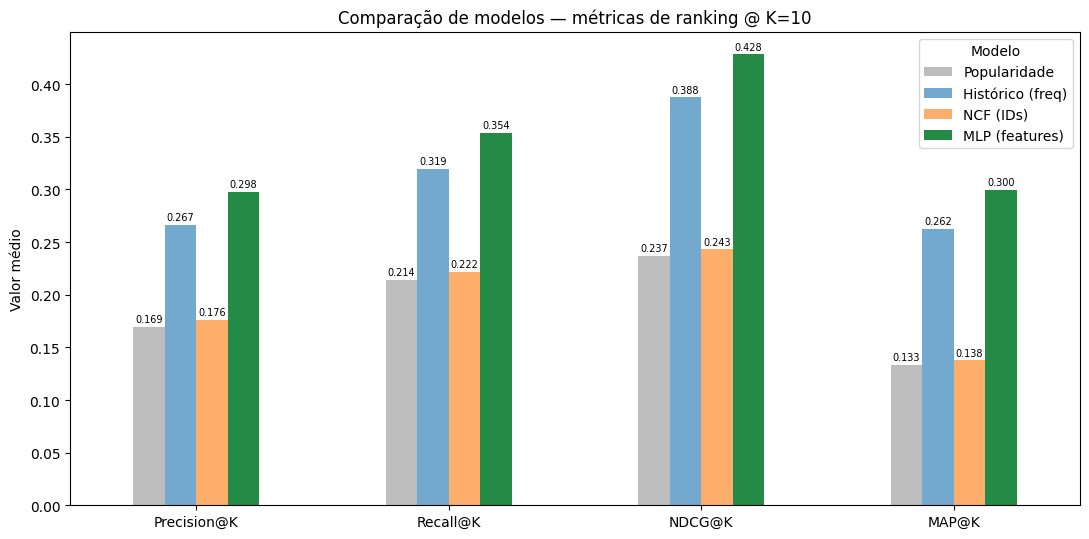

In [12]:
k = 10
metric_names = list(METRICS)
sub = comparison[comparison['k'] == k].set_index('model')[metric_names]
order = ['Popularidade', 'Histórico (freq)', 'NCF (IDs)', 'MLP (features)']
colors = ['#bdbdbd', '#74a9cf', '#fdae6b', '#238b45']

ax = sub.loc[order].T.plot(kind='bar', figsize=(11, 5.5), color=colors)
ax.set_title(f'Comparação de modelos — métricas de ranking @ K={k}')
ax.set_ylabel('Valor médio')
ax.set_xlabel('')
ax.legend(title='Modelo')
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', padding=2, fontsize=7)
plt.tight_layout()
plt.savefig(IMG_DIR / '01_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Salvar modelos, scaler e métricas

In [13]:
torch.save(ncf.state_dict(), MODELS_DIR / 'ncf.pt')
torch.save(feature_mlp.state_dict(), MODELS_DIR / 'feature_mlp.pt')

scaler = {'mean': mu.to_dict(), 'std': sd.to_dict(),
          'feature_cols': FEATURE_COLS, 'log_cols': LOG_COLS}
(MODELS_DIR / 'feature_mlp_scaler.json').write_text(json.dumps(scaler, indent=2))

comparison.to_parquet(PROCESSED_DIR / 'model_comparison.parquet', index=False)
history.to_parquet(PROCESSED_DIR / 'feature_mlp_history.parquet', index=False)
print('Salvos: ncf.pt, feature_mlp.pt, feature_mlp_scaler.json, model_comparison.parquet')
print('\nGanho da MLP sobre o histórico (NDCG@10):',
      f"{comparison.query('model == \"MLP (features)\" and k == 10')['NDCG@K'].iloc[0]:.4f}",
      'vs',
      f"{comparison.query('model == \"Histórico (freq)\" and k == 10')['NDCG@K'].iloc[0]:.4f}")

Salvos: ncf.pt, feature_mlp.pt, feature_mlp_scaler.json, model_comparison.parquet

Ganho da MLP sobre o histórico (NDCG@10): 0.4284 vs 0.3875


## 8. Resumo

- A **MLP com features** é o melhor modelo em todas as métricas, superando o forte
  baseline de **histórico** — graças à **recência** e às demais features, que os
  baselines não têm.
- O **NCF de IDs puros** fica ≈ popularidade: *collaborative filtering* sozinho
  **não captura frequência/recência**, confirmando empiricamente a motivação do
  `notebook 05`.
- *Early stopping* no NDCG@10 evita overfitting (a MLP atinge o pico cedo).
- Artefatos salvos: pesos dos dois modelos, *scaler* das features e a tabela de
  comparação — insumos para o **MLflow Registry** e o **Model Card** (próximas
  etapas).

**Próximos passos:** rastrear estes runs no **MLflow** (promover a MLP a
*Production*), escrever o **Model Card** e refatorar os notebooks validados para
`src/` (Factory de modelos, Strategy de preprocessors).